# Workout Recommendation Model Training

This notebook trains using this models:
- `data/programs_detailed.csv` for workout-program recommendation
- `data/gym_members_exercise_tracking.csv` for calorie prediction

In [1]:
from pathlib import Path
import ast
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

In [2]:
BASE_DIR = Path.cwd()
if not (BASE_DIR / "data").exists():
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "model"
MODEL_DIR.mkdir(exist_ok=True)

PROGRAM_FILE = DATA_DIR / "programs_detailed.csv"
CALORIE_FILE = DATA_DIR / "gym_members_exercise_tracking.csv"

print("Base:", BASE_DIR)
print("Program data:", PROGRAM_FILE.exists())
print("Calorie data:", CALORIE_FILE.exists())

Base: c:\New folder (2)\wrs_updated
Program data: True
Calorie data: True


## 1. Load the datasets

In [3]:
programs = pd.read_csv(PROGRAM_FILE)
calories = pd.read_csv(CALORIE_FILE)

print("Programs:", programs.shape)
print("Calorie records:", calories.shape)
print("Program columns:", programs.columns.tolist())
print("Calorie columns:", calories.columns.tolist())

Programs: (605033, 16)
Calorie records: (973, 15)
Program columns: ['title', 'description', 'level', 'goal', 'equipment', 'program_length', 'time_per_workout', 'week', 'day', 'number_of_exercises', 'exercise_name', 'sets', 'reps', 'intensity', 'created', 'last_edit']
Calorie columns: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']


## 2. Clean program descriptions

In [4]:
def parse_tags(value):
    if pd.isna(value):
        return []
    try:
        value = ast.literal_eval(value)
        return value if isinstance(value, list) else [str(value)]
    except (ValueError, SyntaxError):
        return [str(value)]

for column in ["level", "goal"]:
    if column in programs.columns:
        programs[column + "_list"] = programs[column].apply(parse_tags)

for column in ["title", "description", "equipment"]:
    if column in programs.columns:
        programs[column] = programs[column].fillna("").astype(str)

programs["search_text"] = (
    programs["title"] + " " +
    programs["description"] + " " +
    programs.get("level", "") + " " +
    programs.get("goal", "") + " " +
    programs.get("equipment", "")
).str.replace(r"\s+", " ", regex=True).str.strip()

programs = programs[programs["search_text"].str.len() > 0].reset_index(drop=True)
print("Usable real programs:", len(programs))

Usable real programs: 605033


## 3. Train the data program recommender

In [5]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

program_matrix = vectorizer.fit_transform(programs["search_text"])

joblib.dump(vectorizer, MODEL_DIR / "program_vectorizer.pkl")
joblib.dump(program_matrix, MODEL_DIR / "program_tfidf_matrix.pkl")
programs.to_pickle(MODEL_DIR / "program_catalog.pkl")

print("TF-IDF matrix:", program_matrix.shape)
print("Saved real-data recommender files.")

TF-IDF matrix: (605033, 61774)
Saved real-data recommender files.


## 4. Match a user to programs

In [6]:
GOAL_TAGS = {
    "Weight Loss": ["Weight Loss", "Fat Loss", "Cardio"],
    "Muscle Gain": ["Bodybuilding", "Muscle & Sculpting", "Powerbuilding", "Strength"],
    "Endurance": ["Athletics", "Endurance", "Cardio"],
    "General Fitness": ["Bodyweight Fitness", "Athletics", "Fitness"]
}

LEVEL_TAGS = {
    "Beginner": ["Beginner", "Novice"],
    "Intermediate": ["Intermediate"],
    "Advanced": ["Advanced"]
}

EQUIPMENT_TAGS = {
    "No Equipment": ["At Home", "Bodyweight"],
    "Dumbbells Only": ["Dumbbell Only", "Garage Gym", "At Home"],
    "Full Gym": ["Full Gym", "Garage Gym"]
}

def recommend_real_programs(goal, experience, equipment, top_n=10):
    query = f"{goal} {experience} {equipment}"
    query_vector = vectorizer.transform([query])
    scores = cosine_similarity(query_vector, program_matrix).ravel()

    candidates = programs.copy()
    candidates["similarity"] = scores

    goal_tags = GOAL_TAGS.get(goal, [])
    level_tags = LEVEL_TAGS.get(experience, [])
    equipment_tags = EQUIPMENT_TAGS.get(equipment, [])

    def has_tag(values, wanted):
        return any(item.lower() in {x.lower() for x in values} for item in wanted)

    candidates["goal_match"] = candidates.get("goal_list", pd.Series([[]] * len(candidates))).apply(lambda x: has_tag(x, goal_tags))
    candidates["level_match"] = candidates.get("level_list", pd.Series([[]] * len(candidates))).apply(lambda x: has_tag(x, level_tags))
    candidates["equipment_match"] = candidates["equipment"].apply(lambda x: any(t.lower() in x.lower() for t in equipment_tags))

    candidates["match_score"] = (
        candidates["similarity"]
        + candidates["goal_match"] * 0.35
        + candidates["level_match"] * 0.25
        + candidates["equipment_match"] * 0.25
    )

    return candidates.sort_values("match_score", ascending=False).head(top_n).copy()

example = recommend_real_programs("Muscle Gain", "Intermediate", "Full Gym", 5)
example[["title", "match_score"]]

,title,match_score
578230,ChatGPT,1.282215
578231,ChatGPT,1.282215
578232,ChatGPT,1.282215
578243,ChatGPT,1.282215
578244,ChatGPT,1.282215


### Visualize the top program matches


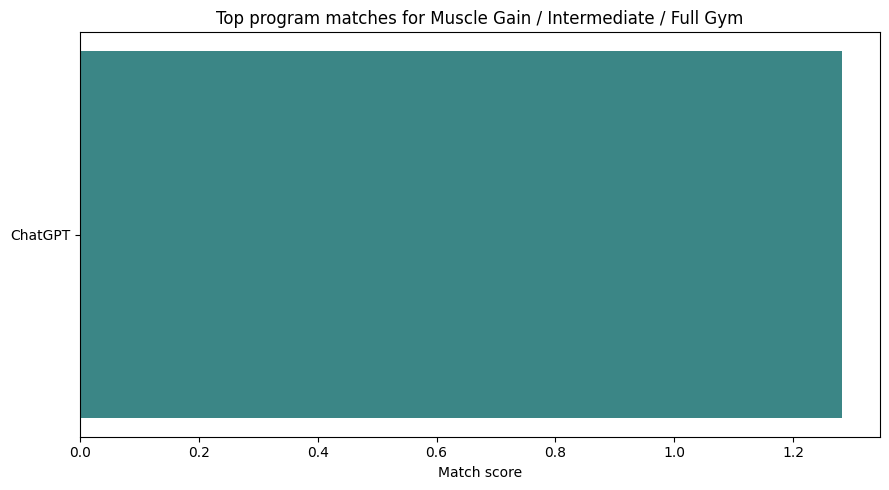

In [7]:
plt.figure(figsize=(9, 5))
plt.barh(example["title"], example["match_score"], color="#3B8686")
plt.xlabel("Match score")
plt.title("Top program matches for Muscle Gain / Intermediate / Full Gym")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 5. Merge matched real programs into one plan

In [8]:
SET_REP_PATTERNS = [
    re.compile(r"(?P<name>[A-Za-z][A-Za-z0-9'()\-/ ]{1,80}?)\s+(?P<sets>\d+)\s*[x×]\s*(?P<target>\d+(?:[-–]\d+)?(?:\s*(?:reps?|sec(?:onds)?|mins?|minutes?|meters?|m))?)", re.I),
    re.compile(r"(?P<name>[A-Za-z][A-Za-z0-9'()\-/ ]{1,80}?)\s*[:\-]\s*(?P<sets>\d+)\s*[x×]\s*(?P<target>\d+(?:[-–]\d+)?)", re.I)
]

def extract_workout_details(text):
    text = re.sub(r"\s+", " ", str(text)).strip()
    found = []
    seen = set()
    for pattern in SET_REP_PATTERNS:
        for match in pattern.finditer(text):
            name = re.sub(r"\s+", " ", match.group("name")).strip(" -:.,")
            sets = match.group("sets")
            target = match.group("target").strip()
            if len(name) < 3:
                continue
            key = (name.lower(), sets, target.lower())
            if key not in seen:
                seen.add(key)
                found.append({
                    "exercise": name,
                    "sets_reps": f"{sets} x {target}"
                })
    return found

def build_one_plan(matches):
    exercises = []
    seen = set()
    source_programs = []

    for _, row in matches.iterrows():
        source_programs.append(row["title"])
        details = extract_workout_details(row.get("description", ""))
        for item in details:
            key = (item["exercise"].lower(), item["sets_reps"].lower())
            if key not in seen:
                seen.add(key)
                exercises.append(item)

    return {
        "source_programs": list(dict.fromkeys(source_programs)),
        "exercises": exercises
    }

one_plan = build_one_plan(example)
print("Source programs merged:")
for title in one_plan["source_programs"]:
    print("-", title)

print("\nMerged real exercise details:")
for item in one_plan["exercises"]:
    print(f"- {item['exercise']}: {item['sets_reps']}")

Source programs merged:
- ChatGPT

Merged real exercise details:


### Explore the calorie dataset


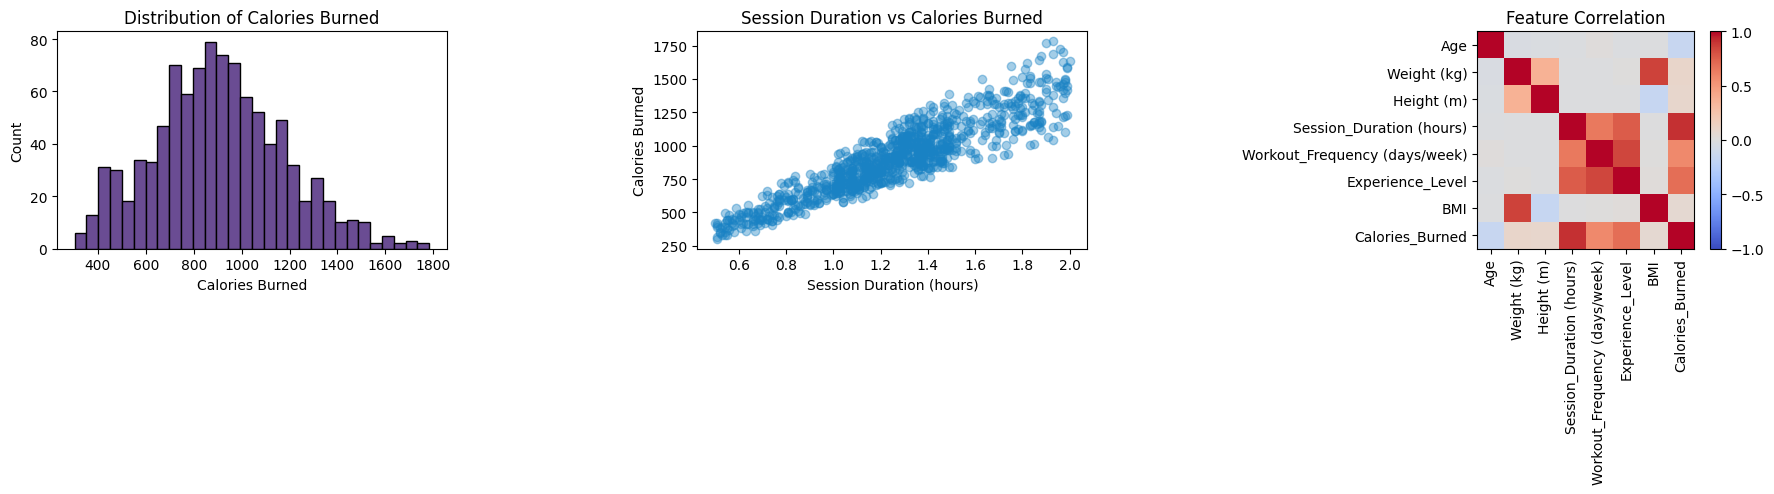

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(calories["Calories_Burned"], bins=30, color="#6A4C93", edgecolor="black")
axes[0].set_xlabel("Calories Burned")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Calories Burned")

axes[1].scatter(calories["Session_Duration (hours)"], calories["Calories_Burned"],
                alpha=0.4, color="#1982C4")
axes[1].set_xlabel("Session Duration (hours)")
axes[1].set_ylabel("Calories Burned")
axes[1].set_title("Session Duration vs Calories Burned")

numeric_cols = ["Age", "Weight (kg)", "Height (m)", "Session_Duration (hours)",
                "Workout_Frequency (days/week)", "Experience_Level", "BMI", "Calories_Burned"]
corr = calories[numeric_cols].corr()
im = axes[2].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[2].set_xticks(range(len(numeric_cols)))
axes[2].set_xticklabels(numeric_cols, rotation=90)
axes[2].set_yticks(range(len(numeric_cols)))
axes[2].set_yticklabels(numeric_cols)
axes[2].set_title("Feature Correlation")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## 6. Load and prepare the real calorie dataset

In [10]:
calories = calories.dropna().copy()

print(calories.head())
print("\nMissing values:")
print(calories.isna().sum())

   Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0   56    Male         88.3        1.71      180      157           60   
1   46  Female         74.9        1.53      179      151           66   
2   32  Female         68.1        1.66      167      122           54   
3   25    Male         53.2        1.70      190      164           56   
4   38    Male         46.1        1.79      188      158           68   

   Session_Duration (hours)  Calories_Burned Workout_Type  Fat_Percentage  \
0                      1.69           1313.0         Yoga            12.6   
1                      1.30            883.0         HIIT            33.9   
2                      1.11            677.0       Cardio            33.4   
3                      0.59            532.0     Strength            28.8   
4                      0.64            556.0     Strength            29.2   

   Water_Intake (liters)  Workout_Frequency (days/week)  Experience_Level  \
0              

## 7. Train the calorie model using only real records

In [11]:
target = "Calories_Burned"

features = [
    "Age",
    "Gender",
    "Weight (kg)",
    "Height (m)",
    "Session_Duration (hours)",
    "Workout_Frequency (days/week)",
    "Experience_Level",
    "BMI",
]

X = calories[features].copy()
y = calories[target].copy()

categorical = ["Gender"]
numeric = [
    "Age",
    "Weight (kg)",
    "Height (m)",
    "Session_Duration (hours)",
    "Workout_Frequency (days/week)",
    "Experience_Level",
    "BMI",
]

preprocessor = ColumnTransformer([
    ("num", "passthrough", numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

calorie_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )),
])

calorie_model.fit(X_train, y_train)

pred = calorie_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 86.00
RMSE: 108.16
R²  : 0.8598


## 7b. Visualize model performance

Three standard regression diagnostics: predicted vs actual, the residual (error) distribution, and which features the Random Forest relied on most.


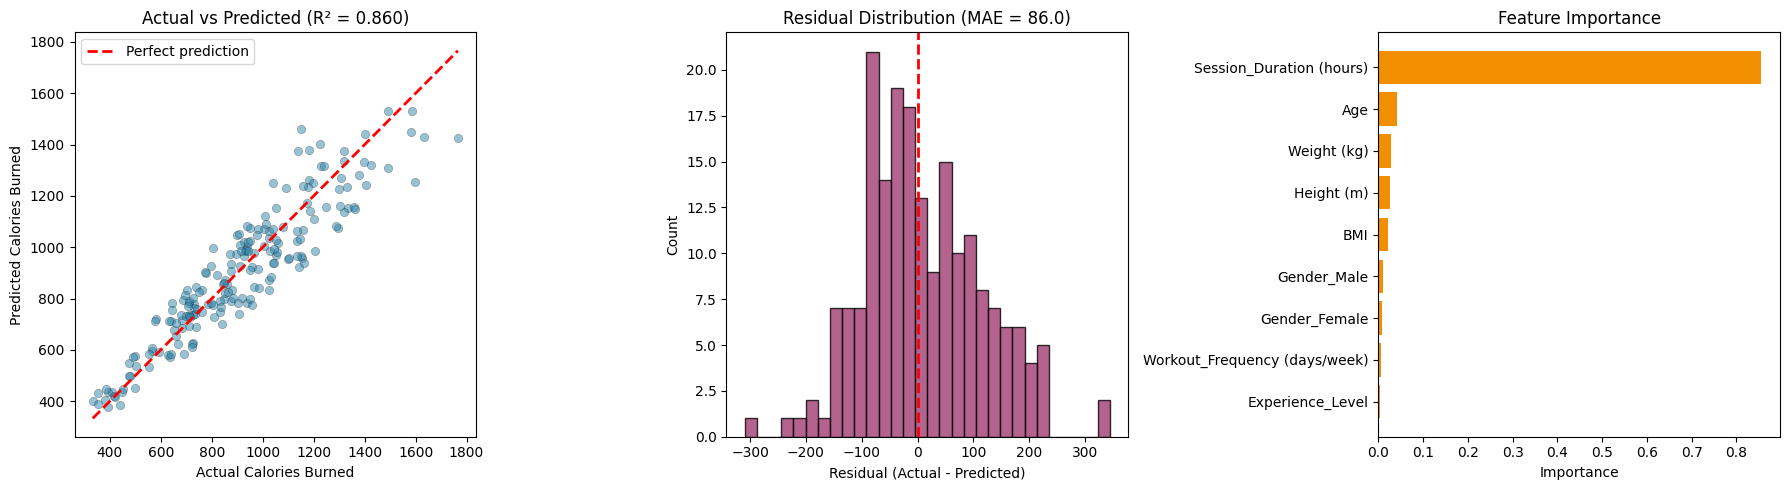

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Actual vs Predicted ---
axes[0].scatter(y_test, pred, alpha=0.5, color="#2E86AB", edgecolor="k", linewidth=0.3)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
axes[0].plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel("Actual Calories Burned")
axes[0].set_ylabel("Predicted Calories Burned")
axes[0].set_title(f"Actual vs Predicted (R\u00b2 = {r2:.3f})")
axes[0].legend()

# --- Residuals ---
residuals = y_test.values - pred
axes[1].hist(residuals, bins=30, color="#A23B72", edgecolor="black", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residual Distribution (MAE = {mae:.1f})")

# --- Feature importance ---
ohe = calorie_model.named_steps["preprocessor"].named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(categorical))
feature_names = numeric + cat_names
importances = calorie_model.named_steps["model"].feature_importances_
order = np.argsort(importances)

axes[2].barh(np.array(feature_names)[order], importances[order], color="#F18F01")
axes[2].set_xlabel("Importance")
axes[2].set_title("Feature Importance")

plt.tight_layout()
plt.show()


### Sample of actual vs predicted values (test set)


In [13]:
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": np.round(pred, 1),
})
results_df["Error"] = np.round(results_df["Actual"] - results_df["Predicted"], 1)
results_df["Abs % Error"] = np.round((results_df["Error"].abs() / results_df["Actual"]) * 100, 1)
results_df.reset_index(drop=True).head(15)


,Actual,Predicted,Error,Abs % Error
0,929.0,983.8,-54.8,5.9
1,1401.0,1443.0,-42.0,3.0
2,925.0,1021.6,-96.6,10.4
3,1155.0,957.0,198.0,17.1
4,1587.0,1531.8,55.2,3.5
5,1247.0,1155.3,91.7,7.4
6,950.0,1024.1,-74.1,7.8
7,927.0,966.0,-39.0,4.2
8,1053.0,969.7,83.3,7.9
9,1201.0,1111.0,90.0,7.5


## 8. Save the real-data calorie model

In [14]:
joblib.dump(calorie_model, MODEL_DIR / "calorie_model.pkl")
joblib.dump(list(X.columns), MODEL_DIR / "calorie_feature_order.pkl")

with open(MODEL_DIR / "calorie_metrics.txt", "w", encoding="utf-8") as f:
    f.write(f"MAE: {mae:.4f}\n")
    f.write(f"RMSE: {rmse:.4f}\n")
    f.write(f"R2: {r2:.4f}\n")

print("Saved calorie_model.pkl")

Saved calorie_model.pkl


## 10. Try the calorie model on a new (unseen) user

This shows the model being used the same way `app.py` uses it: build a one-row DataFrame in the exact feature order the pipeline expects, then call `.predict()`.


In [15]:
sample_user = pd.DataFrame([{
    "Age": 28,
    "Gender": "Male",
    "Weight (kg)": 78,
    "Height (m)": 1.78,
    "Session_Duration (hours)": 1.1,
    "Workout_Frequency (days/week)": 4,
    "Experience_Level": 2,
    "BMI": 78 / (1.78 ** 2),
}])[X.columns]

predicted_calories = calorie_model.predict(sample_user)[0]
print("Sample user:")
print(sample_user.to_string(index=False))
print(f"\nPredicted Calories Burned: {predicted_calories:.1f} kcal")


Sample user:
 Age Gender  Weight (kg)  Height (m)  Session_Duration (hours)  Workout_Frequency (days/week)  Experience_Level       BMI
  28   Male           78        1.78                       1.1                              4                 2 24.618104

Predicted Calories Burned: 839.0 kcal


## 9. Real-data training summary

In [16]:
print("Program recommender")
print("- Source: programs_detailed.csv")
print("- Method: TF-IDF + cosine similarity")
print("- Training rows:", len(programs))

print("\nCalorie model")
print("- Source: gym_members_exercise_tracking.csv")
print("- Model: Random Forest Regressor")
print("- Training rows:", len(X_train))
print("- Test rows:", len(X_test))
print(f"- Test R²: {r2:.4f}")

Program recommender
- Source: programs_detailed.csv
- Method: TF-IDF + cosine similarity
- Training rows: 605033

Calorie model
- Source: gym_members_exercise_tracking.csv
- Model: Random Forest Regressor
- Training rows: 778
- Test rows: 195
- Test R²: 0.8598
